Task 3

In [ ]:
import pandas as pd

In [ ]:
#Load the dataset
data_frame=pd.read_csv('/content/Breast_Cancer_Mortality_Survival_Dataset.csv')

In [ ]:
#Display the first five rows of the dataset
data_frame.head()

,Patient ID,Moth of Birth,Age,Sex,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,...,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Mortality_Status
0,A0012,12,68.0,Female,White,Married,11.0,1,T1,N1,...,Poorly differentiated,3,Regional,4.0,Positive,Positive,24,1,60,Alive
1,A0013,12,50.0,Female,White,Married,11.0,0,T2,N2,...,Moderately differentiated,2,Regional,35.0,Positive,Positive,14,5,62,Alive
2,A0014,11,58.0,Female,White,Divorced,9.0,0,T3,N3,...,Moderately differentiated,2,Regional,63.0,Positive,Positive,14,7,75,Alive
3,A0015,3,58.0,Female,White,Married,10.0,0,T1,N1,...,Poorly differentiated,3,Regional,18.0,Positive,Positive,2,1,84,Alive
4,A0016,1,47.0,Female,White,Married,12.0,0,T2,N1,...,Poorly differentiated,3,Regional,41.0,Positive,Positive,3,1,50,Alive


In [ ]:
# Display info about the data
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient ID              4024 non-null   object 
 1   Moth of Birth           4024 non-null   int64  
 2   Age                     4015 non-null   float64
 3   Sex                     3947 non-null   object 
 4   Race                    4024 non-null   object 
 5   Marital Status          4024 non-null   object 
 6   Occupation Code         4021 non-null   float64
 7   Adopted Status          4024 non-null   int64  
 8   T Stage                 4024 non-null   object 
 9   N Stage                 4024 non-null   object 
 10  6th Stage               4024 non-null   object 
 11  differentiate           4024 non-null   object 
 12  Grade                   4024 non-null   int64  
 13  A Stage                 4024 non-null   object 
 14  Tumor Size              4021 non-null   

In [ ]:
#Correct column names
data_frame.rename(columns={'Moth of Birth':'Month of Birth', 'Tumor Size':'Tumour Size', 'Reginol Node Positive':'Regional Node Positive'}, inplace=True)

In [ ]:
#Drop variables
data_frame.drop(['Sex', 'Patient ID ', 'Month of Birth', 'Occupation Code', 'Adopted Status'], axis=1, inplace=True)

In [ ]:
#Ceck for missing values
missing_values=data_frame.isnull().sum()

In [ ]:
#Display data set and missing values
print(data_frame, missing_values)

       Age   Race Marital Status T Stage  N Stage 6th Stage  \
0     68.0  White        Married       T1      N1       IIA   
1     50.0  White        Married       T2      N2      IIIA   
2     58.0  White       Divorced       T3      N3      IIIC   
3     58.0  White        Married       T1      N1       IIA   
4     47.0  White        Married       T2      N1       IIB   
...    ...    ...            ...      ...     ...       ...   
4019  62.0  Other        Married       T1      N1       IIA   
4020  56.0  White       Divorced       T2      N2      IIIA   
4021  68.0  White        Married       T2      N1       IIB   
4022  58.0  Black       Divorced       T2      N1       IIB   
4023  46.0  White        Married       T2      N1       IIB   

                  differentiate  Grade   A Stage  Tumour Size Estrogen Status  \
0         Poorly differentiated      3  Regional          4.0        Positive   
1     Moderately differentiated      2  Regional         35.0        Positive   


In [ ]:
# Define integer columns that need to be processed
int_column=['Age','Tumour Size']

In [ ]:
# Define object columns (categorical data) that need to be processed
object_column=['Grade']

In [ ]:
# Fill missing values in integer columns with 0 and convert them to integers
data_frame[int_column]=data_frame[int_column].fillna(0).astype(int)

In [ ]:
# Convert object columns to object type
data_frame[object_column]=data_frame[object_column].astype('object')

In [ ]:
# Check unique values in Mortality_Status column
data_frame.Mortality_Status.unique()

array(['Alive', 'Dead', nan, 'ALIVE', 'DEAD', 'alive', 'dead'],
      dtype=object)

In [ ]:
# Convert Mortality_Status to lowercase
data_frame['Mortality_Status']=data_frame['Mortality_Status'].str.lower()

In [ ]:
# Replace string values in Mortality_Status with numeric equivalents
data_frame=data_frame.replace({'alive':0, 'dead':1})

<ipython-input-233-f304870d1942>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame=data_frame.replace({'alive':0, 'dead':1})


In [ ]:
# Fill missing values
data_frame['Age'].fillna(data_frame['Age'].median(), inplace=True)
data_frame['Tumour Size'].fillna(data_frame['Tumour Size'].median(), inplace=True)
data_frame['Survival Months'].fillna(data_frame['Survival Months'].mode(), inplace=True)
data_frame['Mortality_Status'].fillna(data_frame['Mortality_Status'].mode(), inplace=True)

<ipython-input-234-2e3841eb36f5>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_frame['Age'].fillna(data_frame['Age'].median(), inplace=True)
<ipython-input-234-2e3841eb36f5>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
# Check for missing values in the data
data_frame.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumour Size,0


In [ ]:
# Convert Regional Node Examined to numeric values, Fill missing values with the mode and Convert column to integer type

data_frame['Regional Node Examined']=pd.to_numeric(data_frame['Regional Node Examined'], errors='coerce')
data_frame['Regional Node Examined'].fillna(data_frame['Regional Node Examined'].mode()[0], inplace=True)
data_frame['Regional Node Examined']=data_frame['Regional Node Examined'].astype(int)

<ipython-input-236-1cc0ca17ba41>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_frame['Regional Node Examined'].fillna(data_frame['Regional Node Examined'].mode()[0], inplace=True)


In [ ]:
# Convert Regional Node Positive to numeric values, Fill missing values with the mode and Convert column to integer type

data_frame['Regional Node Positive']=pd.to_numeric(data_frame['Regional Node Positive'], errors='coerce')
data_frame['Regional Node Positive'].fillna(data_frame['Regional Node Positive'].mode()[0], inplace=True)
data_frame['Regional Node Positive']=data_frame['Regional Node Positive'].astype(int)

<ipython-input-237-88ec0fd7ba90>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_frame['Regional Node Positive'].fillna(data_frame['Regional Node Positive'].mode()[0], inplace=True)


In [ ]:
# Fill missing values in Mortality_Status
data_frame['Mortality_Status'].fillna(data_frame['Mortality_Status'].mode()[0], inplace=True)

<ipython-input-238-740d51686896>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_frame['Mortality_Status'].fillna(data_frame['Mortality_Status'].mode()[0], inplace=True)


In [ ]:
# Check if there are still missing values in the dataset
data_frame.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumour Size,0


In [ ]:
#Display clean data set
data_frame.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumour Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Mortality_Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,0.0
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,0.0
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,0.0
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,0.0
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,0.0


In [ ]:
# Display information about the data
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4024 non-null   object 
 2   Marital Status          4024 non-null   object 
 3   T Stage                 4024 non-null   object 
 4   N Stage                 4024 non-null   object 
 5   6th Stage               4024 non-null   object 
 6   differentiate           4024 non-null   object 
 7   Grade                   4024 non-null   int64  
 8   A Stage                 4024 non-null   object 
 9   Tumour Size             4024 non-null   int64  
 10  Estrogen Status         4024 non-null   object 
 11  Progesterone Status     4024 non-null   object 
 12  Regional Node Examined  4024 non-null   int64  
 13  Regional Node Positive  4024 non-null   int64  
 14  Survival Months         4024 non-null   

Task 2

In [ ]:
# Print statistical description of numerical columns
print("Statistical Description:\n", data_frame.describe().transpose())

Statistical Description:
                          count       mean        std   min   25%   50%   75%  \
Age                     4024.0  53.973410  11.687200   0.0  47.0  54.0  61.0   
Grade                   4024.0   2.150596   0.638234   1.0   2.0   2.0   3.0   
Tumour Size             4024.0  30.396620  21.169480 -75.0  16.0  25.0  38.0   
Regional Node Examined  4024.0  14.629722  18.646963   1.0   9.0  14.0  19.0   
Regional Node Positive  4024.0   4.158052   5.109331   1.0   1.0   2.0   5.0   
Survival Months         4024.0  71.472167  25.361855   1.0  56.0  73.0  90.0   
Mortality_Status        4024.0   0.153082   0.360111   0.0   0.0   0.0   0.0   

                           max  
Age                      502.0  
Grade                      4.0  
Tumour Size              140.0  
Regional Node Examined  1080.0  
Regional Node Positive    46.0  
Survival Months          760.0  
Mortality_Status           1.0  


In [ ]:
# Print statistical description of categorical columns
print("Statistical Description:\n", data_frame.describe(include='object').transpose())

Statistical Description:
                     count unique                        top  freq
Race                 4024      3                      White  3413
Marital Status       4024      5                    Married  2643
T Stage              4024      4                         T2  1786
N Stage              4024      3                         N1  2732
6th Stage            4024      5                        IIA  1305
differentiate        4024      4  Moderately differentiated  2351
A Stage              4024      2                   Regional  3932
Estrogen Status      4024      2                   Positive  3755
Progesterone Status  4024      2                   Positive  3326


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

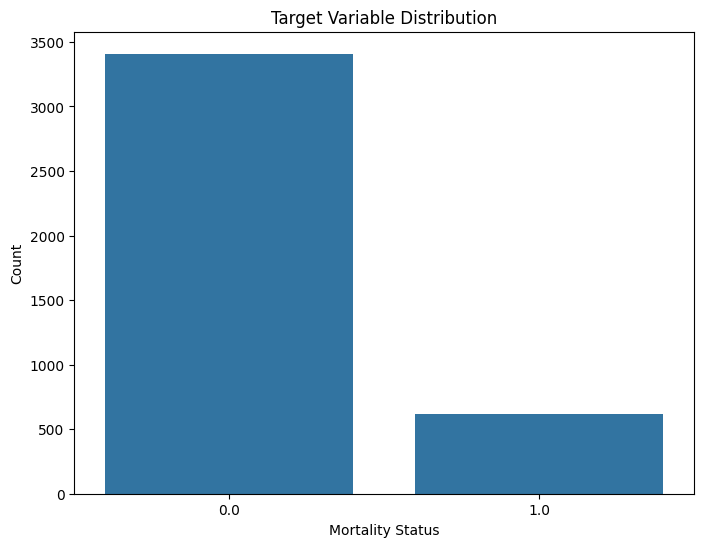

In [ ]:
# Plot target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Mortality_Status', data=data_frame)
plt.title('Target Variable Distribution')
plt.xlabel('Mortality Status')
plt.ylabel('Count')
plt.show()

Task 4

In [ ]:
#print Features Names
features=data_frame.columns
print("Features Names:", features)

Features Names: Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumour Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Regional Node Positive', 'Survival Months', 'Mortality_Status'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
# Define categorical and numeric features
categorical_features = ['Race', 'Marital Status','T Stage ', 'N Stage', 'Estrogen Status', 'Progesterone Status']
numeric_features = ['Age', 'Tumour Size', 'Regional Node Examined', 'Regional Node Positive']

In [ ]:
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [ ]:
# Apply preprocessing to the entire dataset
X = preprocessor.fit_transform(data_frame[categorical_features + numeric_features])
y = data_frame['Mortality_Status']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Check data shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Distribution:\n", y_train.value_counts(normalize=True))
print("y_test Distribution:\n", y_test.value_counts(normalize=True))


X_train Shape: (3219, 17)
X_test Shape: (805, 17)
y_train Distribution:
 Mortality_Status
0.0    0.846847
1.0    0.153153
Name: proportion, dtype: float64
y_test Distribution:
 Mortality_Status
0.0    0.847205
1.0    0.152795
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
# Display feature names and data shape
print("Feature Names After One-Hot Encoding:")
print(preprocessor.get_feature_names_out())

print("\nTraining Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)


Feature Names After One-Hot Encoding:
['num__Age' 'num__Tumour Size' 'num__Regional Node Examined'
 'num__Regional Node Positive' 'cat__Race_Other' 'cat__Race_White'
 'cat__Marital Status_Married' 'cat__Marital Status_Separated'
 'cat__Marital Status_Single ' 'cat__Marital Status_Widowed'
 'cat__T Stage _T2' 'cat__T Stage _T3' 'cat__T Stage _T4'
 'cat__N Stage_N2' 'cat__N Stage_N3' 'cat__Estrogen Status_Positive'
 'cat__Progesterone Status_Positive']

Training Set Shape: (3219, 17)
Test Set Shape: (805, 17)


Task 5

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#prediction
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

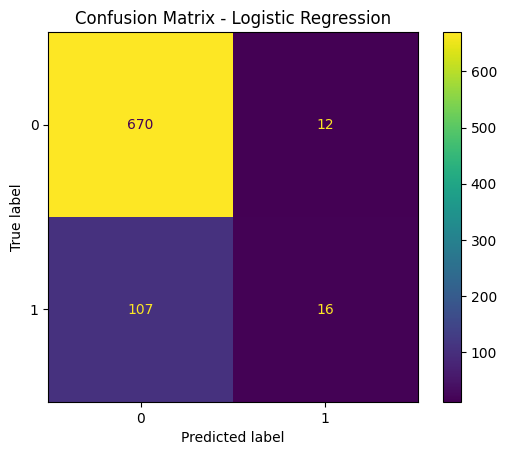

In [ ]:
#Show Confusion Matrix of Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[0, 1])
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

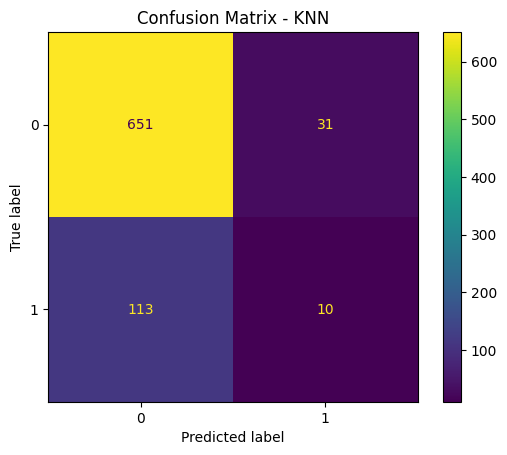

In [ ]:
# Show Confusion Matrix of KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
disp_knn.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

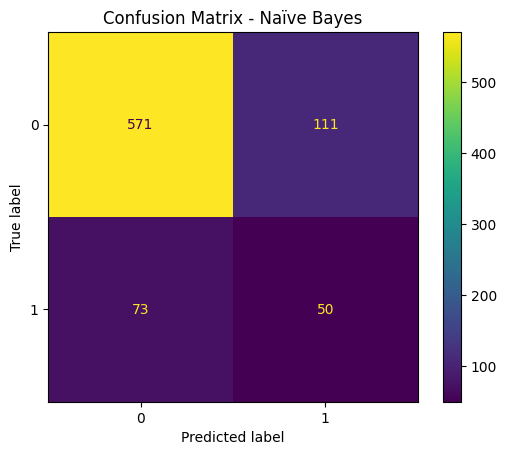

In [ ]:
#Show Confusion Matrix of Naïve Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=[0, 1])
disp_nb.plot()
plt.title("Confusion Matrix - Naïve Bayes")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
# Calculate accuracy, precision, recall, f-score, roc_auc for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label=1.0)
recall_lr = recall_score(y_test, y_pred_lr, pos_label=1.0)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=1.0)
roc_auc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

In [ ]:
#Show results of accuracy, precision, recall, f-score, roc_auc
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1-Score:", f1_lr)
print("AUC-ROC:", roc_auc_lr)


Accuracy: 0.8521739130434782
Precision: 0.5714285714285714
Recall: 0.13008130081300814
F1-Score: 0.2119205298013245
AUC-ROC: 0.7327444388813389


In [ ]:
#Calculate accuracy, precision, recall, f-score, roc_auc for Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label=1.0)
recall_nb = recall_score(y_test, y_pred_nb, pos_label=1.0)
f1_nb = f1_score(y_test, y_pred_nb, pos_label=1.0)
roc_auc_nb = roc_auc_score(y_test, nb_model.predict_proba(X_test)[:, 1])

In [ ]:
#Show results of accuracy, precision, recall, f-score, roc_auc
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-Score:", f1_nb)
print("AUC-ROC:", roc_auc_nb)

Accuracy: 0.7714285714285715
Precision: 0.3105590062111801
Recall: 0.4065040650406504
F1-Score: 0.352112676056338
AUC-ROC: 0.690520468254536


In [ ]:
#Calculate accuracy, precision, recall, f-score, roc_auc for KNneighbour
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label=1.0)
recall_knn = recall_score(y_test, y_pred_knn, pos_label=1.0)
f1_knn = f1_score(y_test, y_pred_knn, pos_label=1.0)
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])

In [ ]:
#Show results of accuracy, precision, recall, f-score, roc_auc
print("Accuracy", accuracy_knn)
print("Precision", precision_knn)
print("Recall", recall_knn)
print("F1-Score", f1_knn)
print("AUC-ROC", roc_auc_knn)

Accuracy 0.8211180124223603
Precision 0.24390243902439024
Recall 0.08130081300813008
F1-Score 0.12195121951219512
AUC-ROC 0.5923276828076198


In [ ]:
#Checking model for overfitting and underfitting
train_accuracy = lr_model.score(X_train, y_train)
test_accuracy = lr_model.score(X_test, y_test)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)


Train Accuracy: 0.8577197887542715
Test Accuracy: 0.8521739130434782


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Define hyperparameter grid
param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}

In [ ]:
# Perform grid search
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [ ]:
# Get best parameters and model
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'C': 10, 'solver': 'liblinear'}


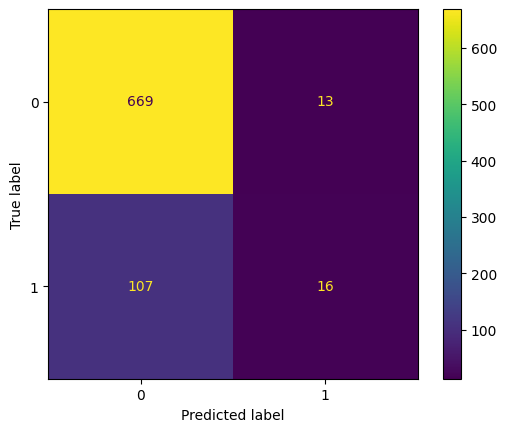

In [ ]:
# Evaluate the tuned model
y_pred_tuned = best_model.predict(X_test)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(confusion_matrix=cm_tuned).plot()

Part B Task 1

In [ ]:
#Show data frame columns
data_frame.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumour Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Regional Node Positive', 'Survival Months', 'Mortality_Status'],
      dtype='object')

In [ ]:
#Show dimensions of the dataset
print("Data Dimentions", data_frame.shape)

Data Dimentions (4024, 16)


In [ ]:
# List the names of the features used for regression modeling
features=data_frame.columns.tolist()

In [ ]:
#Show features names
print("Features Names:")
for feature_name in features:
    print(feature_name)

Features Names:
Age
Race
Marital Status
T Stage 
N Stage
6th Stage
differentiate
Grade
A Stage
Tumour Size
Estrogen Status
Progesterone Status
Regional Node Examined
Regional Node Positive
Survival Months
Mortality_Status


Task 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# List numerical and categorical columns
numerical_columns=data_frame.select_dtypes(include=['int64']).columns
categorical_colmuns=data_frame.select_dtypes(include=['object']).columns

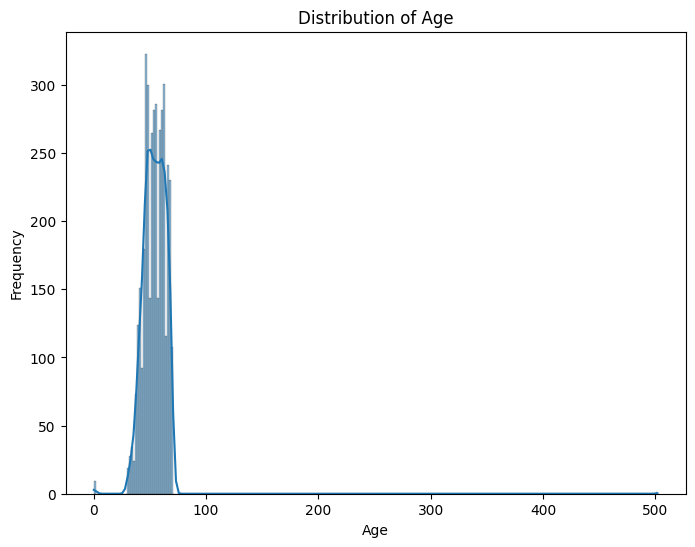

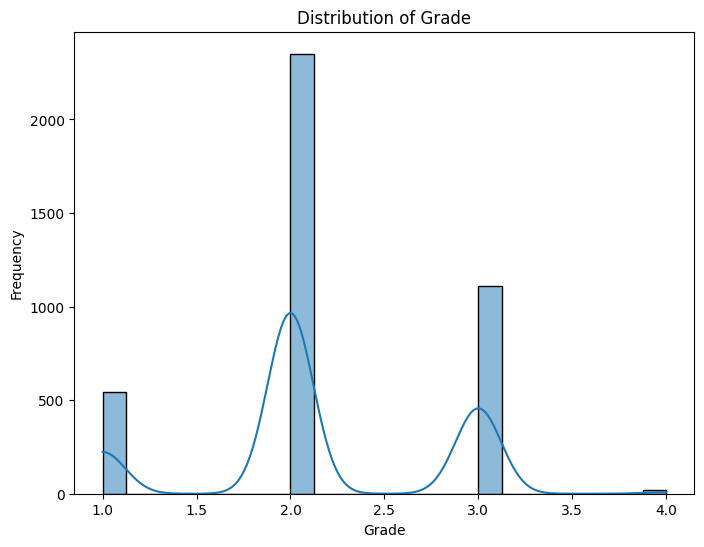

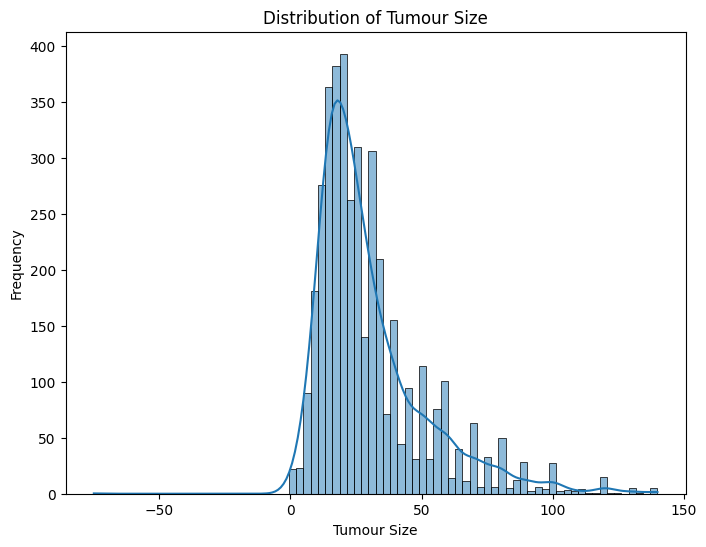

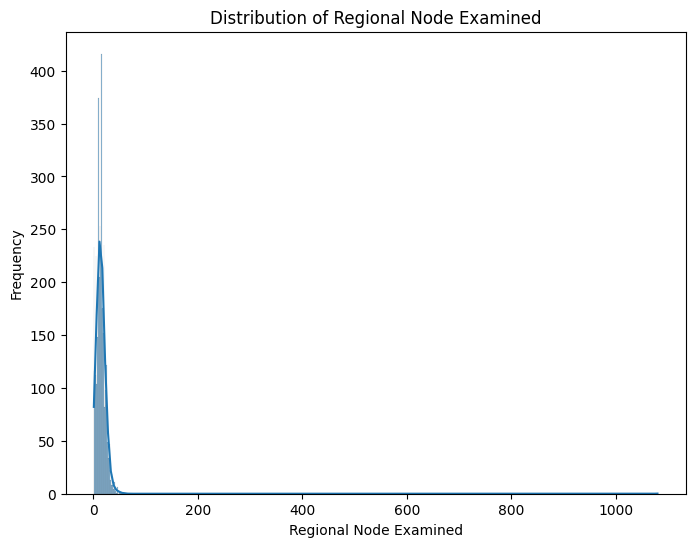

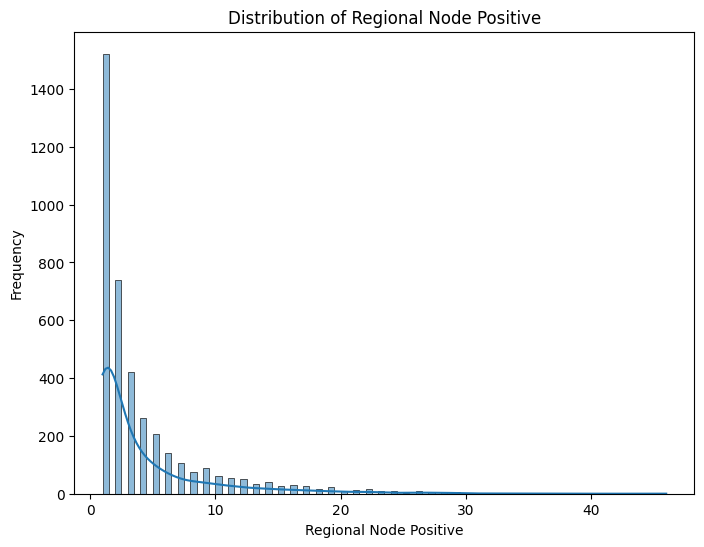

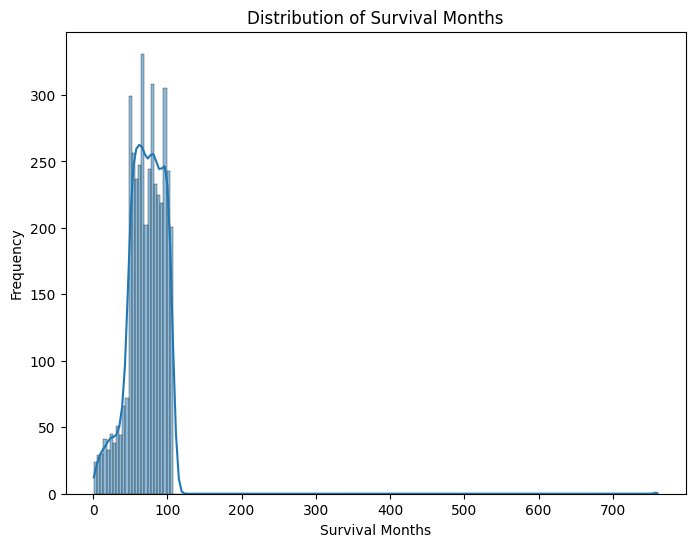

In [ ]:
#Show numerical variable distributions
for column in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(data_frame[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

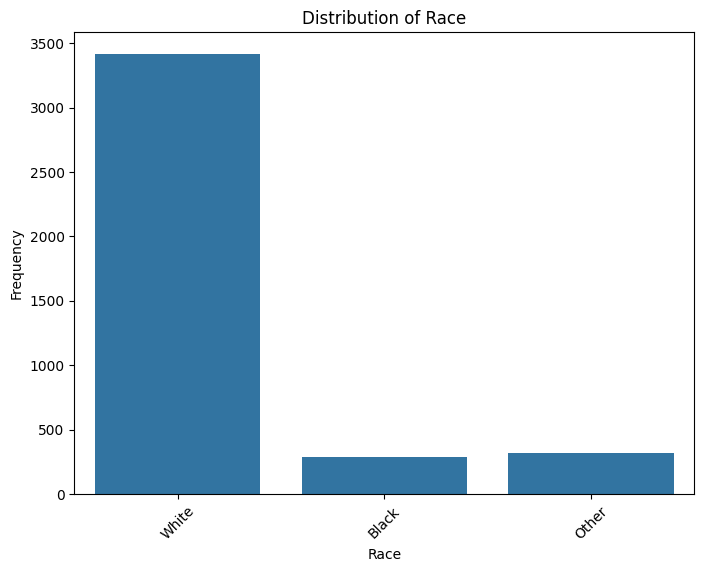

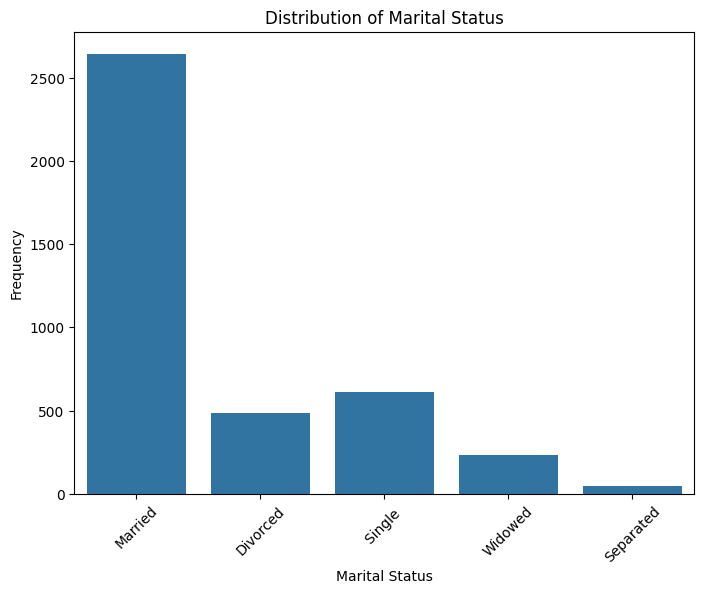

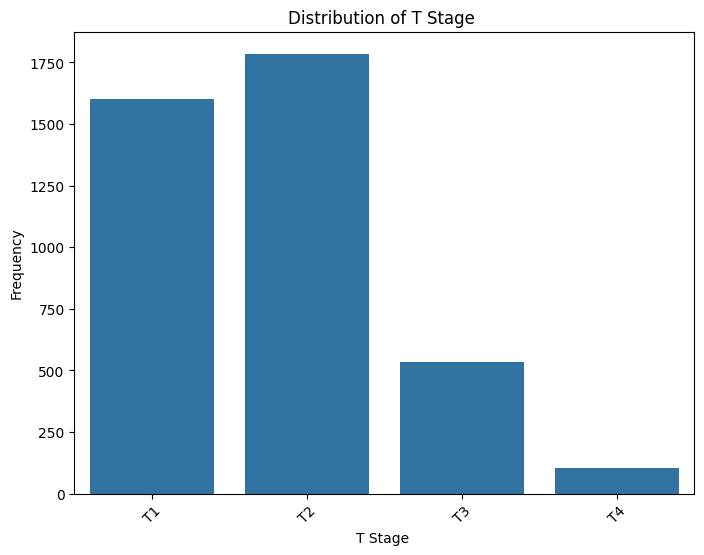

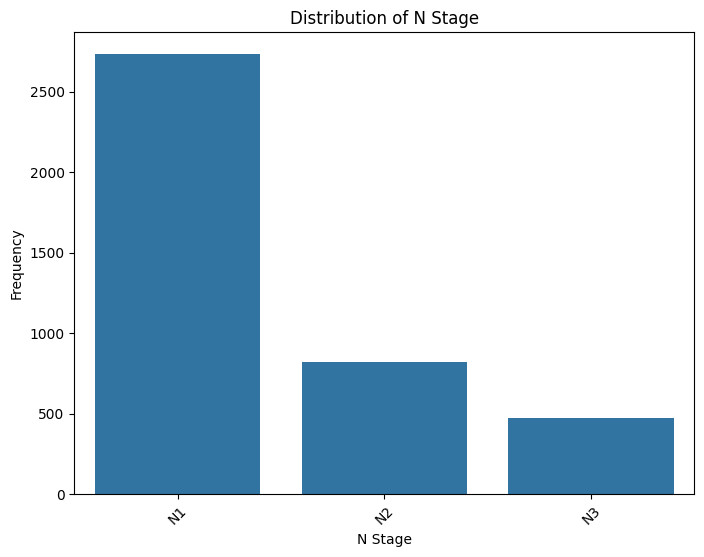

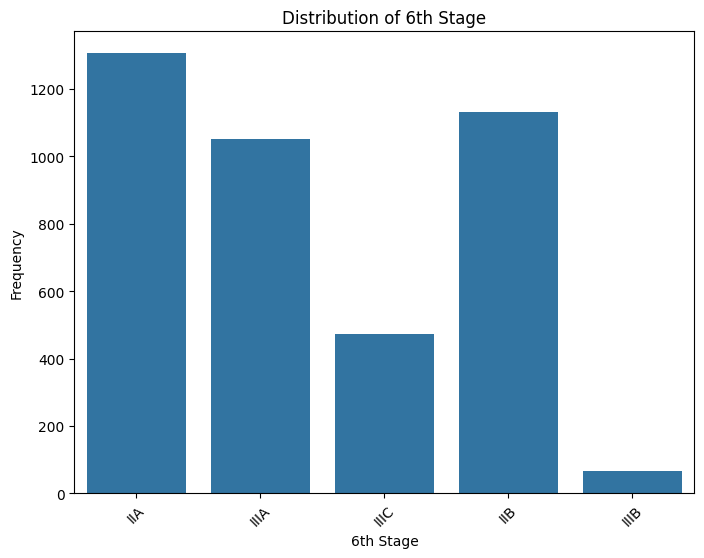

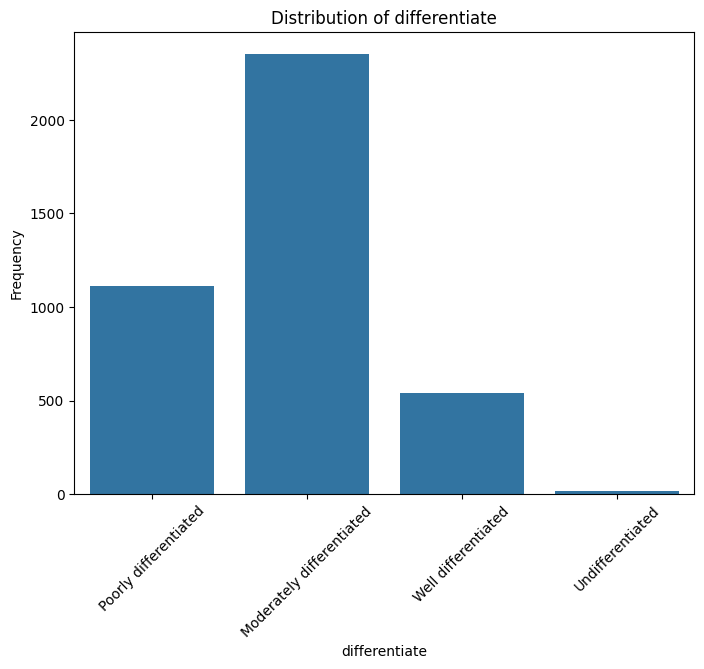

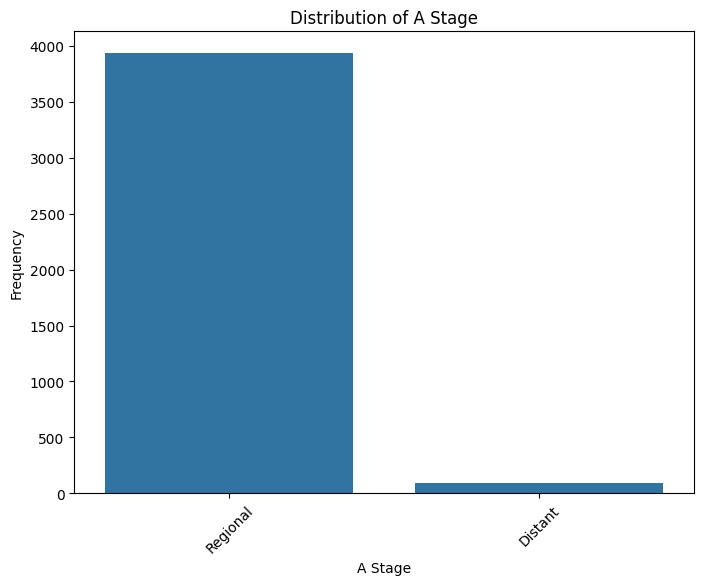

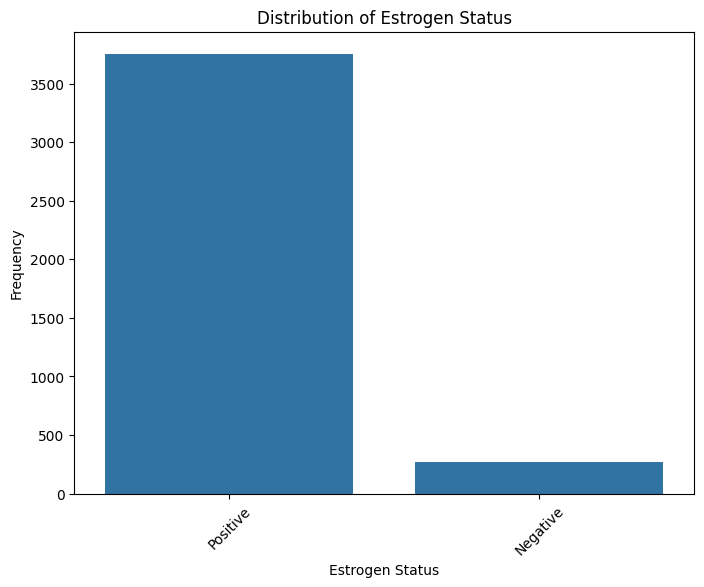

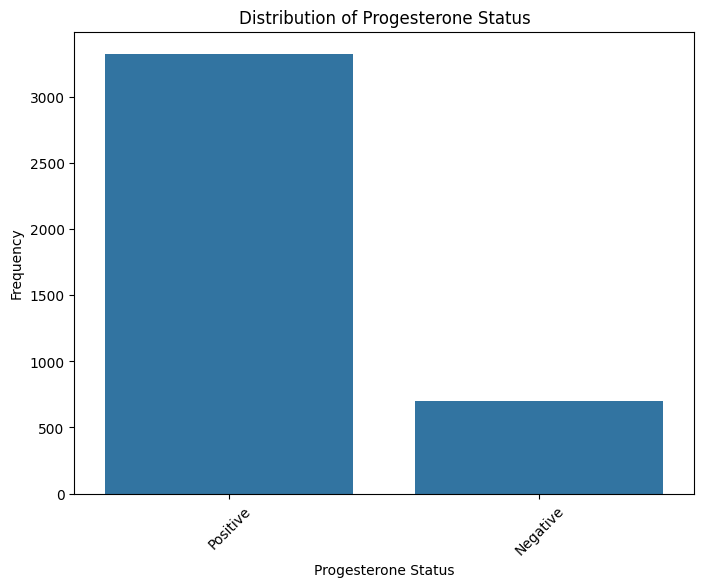

In [ ]:
#Show categorical variable distribution
for column in categorical_colmuns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data_frame, x=column)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

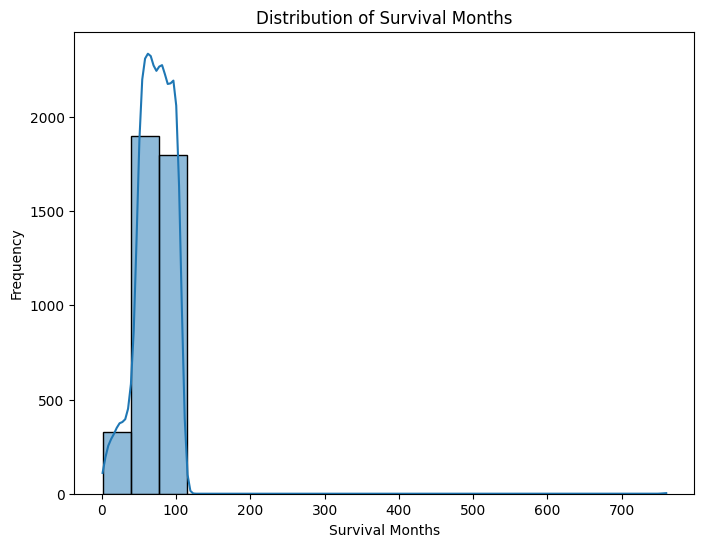

In [ ]:
#Show target variable distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Survival Months'], kde=True, bins=20)
plt.title('Distribution of Survival Months')
plt.xlabel('Survival Months')
plt.ylabel('Frequency')
plt.show()

Task 3

In [ ]:
#Show statistic of numeric features
features=data_frame[numerical_columns]
numerical_stats=features.describe()
print("Numerical Feature Statistics:\n", numerical_stats)

Numerical Feature Statistics:
               Age        Grade  Tumour Size  Regional Node Examined  \
count  4024.00000  4024.000000   4024.00000             4024.000000   
mean     53.97341     2.150596     30.39662               14.629722   
std      11.68720     0.638234     21.16948               18.646963   
min       0.00000     1.000000    -75.00000                1.000000   
25%      47.00000     2.000000     16.00000                9.000000   
50%      54.00000     2.000000     25.00000               14.000000   
75%      61.00000     3.000000     38.00000               19.000000   
max     502.00000     4.000000    140.00000             1080.000000   

       Regional Node Positive  Survival Months  
count             4024.000000      4024.000000  
mean                 4.158052        71.472167  
std                  5.109331        25.361855  
min                  1.000000         1.000000  
25%                  1.000000        56.000000  
50%                  2.000000      

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

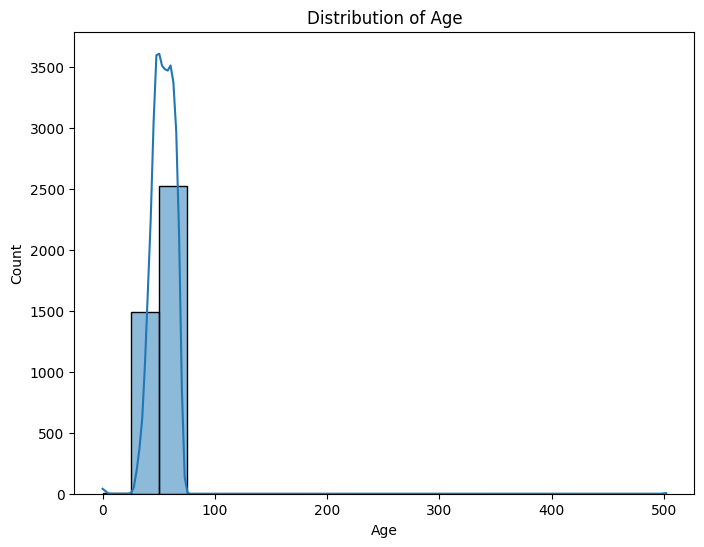

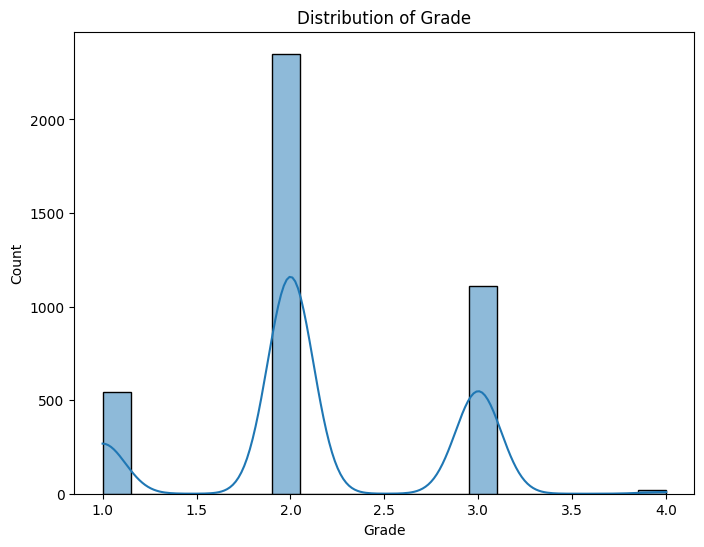

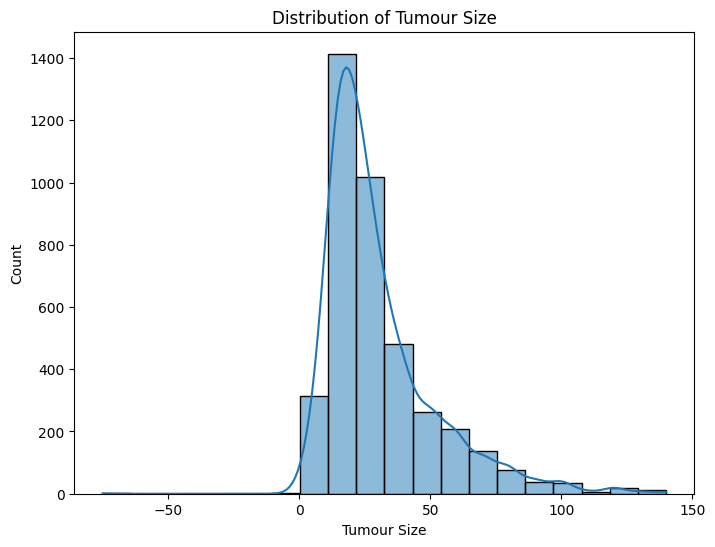

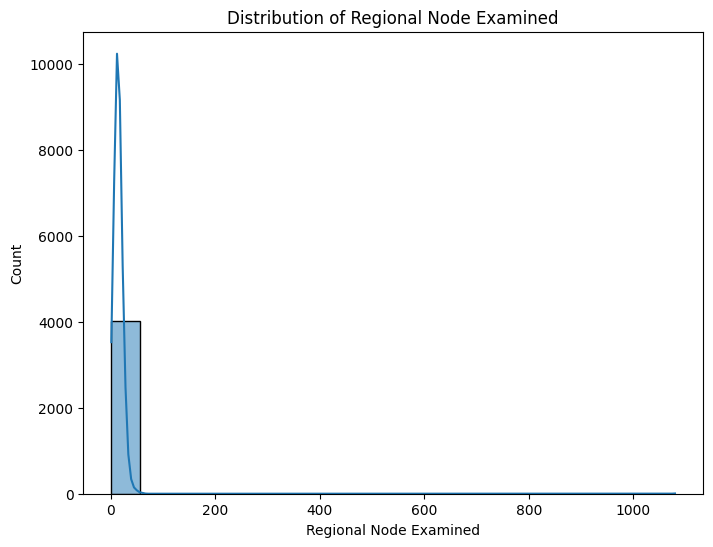

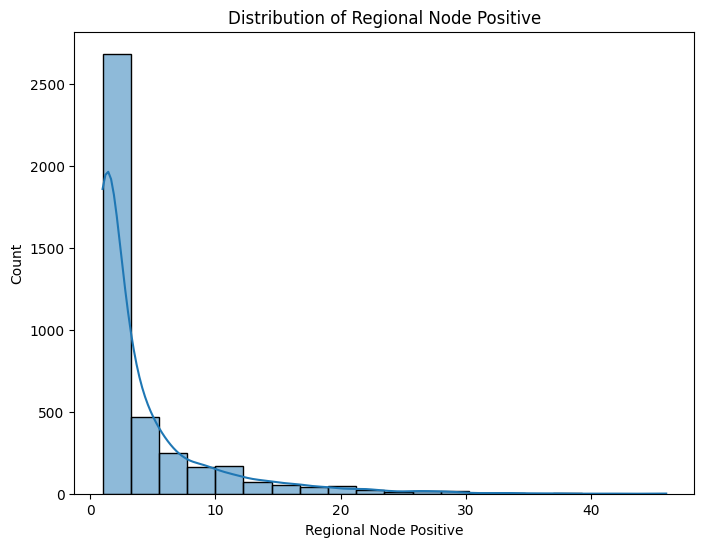

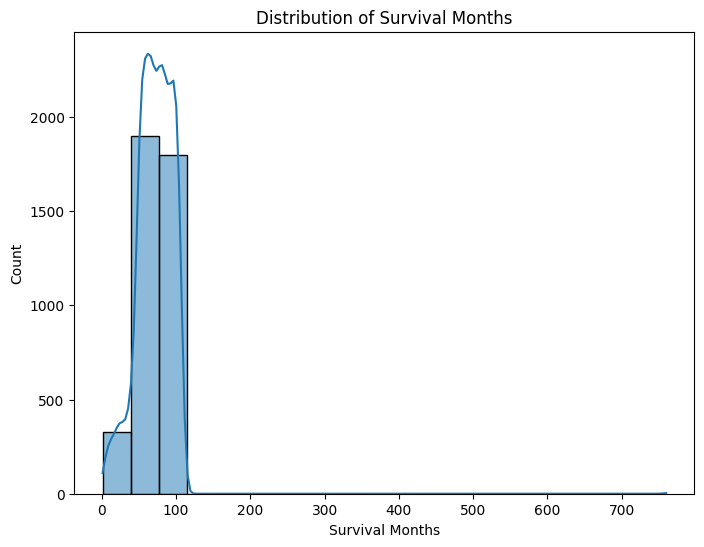

In [ ]:
#Show histogram of numerical features
for col in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(features[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#Scal numerical features
scaler = StandardScaler()
features[numerical_columns] = scaler.fit_transform(features[numerical_columns])

<ipython-input-290-d711e6fe6b6b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[numerical_columns] = scaler.fit_transform(features[numerical_columns])


In [ ]:
#Check scaled numerical features
print("Scaled Numerical Feature Statistics:\n", features.describe())

Scaled Numerical Feature Statistics:
                 Age         Grade   Tumour Size  Regional Node Examined  \
count  4.024000e+03  4.024000e+03  4.024000e+03            4.024000e+03   
mean  -3.266660e-17  2.650851e-16  3.443236e-17           -3.531525e-18   
std    1.000124e+00  1.000124e+00  1.000124e+00            1.000124e+00   
min   -4.618738e+00 -1.803006e+00 -4.979325e+00           -7.310260e-01   
25%   -5.967448e-01 -2.359874e-01 -6.801494e-01           -3.019484e-01   
50%    2.275461e-03 -2.359874e-01 -2.549562e-01           -3.377493e-02   
75%    6.012958e-01  1.331031e+00  3.592117e-01            2.343986e-01   
max    3.833957e+01  2.898050e+00  5.178068e+00            5.714081e+01   

       Regional Node Positive  Survival Months  
count            4.024000e+03     4.024000e+03  
mean             8.961243e-17    -1.589186e-17  
std              1.000124e+00     1.000124e+00  
min             -6.181718e-01    -2.779013e+00  
25%             -6.181718e-01    -6.10132

Task 4

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Define target and features
target = 'Survival Months'
all_features = features.columns.tolist()
numeric_features = numerical_columns

In [ ]:
# Split the data (80:20) for both models
X_numeric = data_frame[numeric_features]
X_all = data_frame[all_features]
y = data_frame[target]

In [ ]:
#Testing and Training both models
X_train_numeric, X_test_numeric, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)
X_train_all, X_test_all, _, _ = train_test_split(X_all, y, test_size=0.2, random_state=42)

In [ ]:
# Build and train Model 1 for Numeric Features
dt_model_numeric = DecisionTreeRegressor(random_state=42)
dt_model_numeric.fit(X_train_numeric, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# Build and train Model 2 for All Features
dt_model_all = DecisionTreeRegressor(random_state=42)
dt_model_all.fit(X_train_all, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# Predict and evaluate both models
y_pred_numeric = dt_model_numeric.predict(X_test_numeric)
y_pred_all = dt_model_all.predict(X_test_all)

In [ ]:
# Print evaluation model 1
print("Model 1 (Numeric Features Only):")
print("MSE:", mean_squared_error(y_test, y_pred_numeric))
print("MAE:", mean_absolute_error(y_test, y_pred_numeric))
print("R2 Score:", r2_score(y_test, y_pred_numeric))

Model 1 (Numeric Features Only):
MSE: 0.002484472049689441
MAE: 0.002484472049689441
R2 Score: 0.9999953514711653


In [ ]:
#Print evaluation model 2
print("\nModel 2 (All Features):")
print("MSE:", mean_squared_error(y_test, y_pred_all))
print("MAE:", mean_absolute_error(y_test, y_pred_all))
print("R2 Score:", r2_score(y_test, y_pred_all))


Model 2 (All Features):
MSE: 0.002484472049689441
MAE: 0.002484472049689441
R2 Score: 0.9999953514711653


In [ ]:
# Print dimensions model 1
print("Model 1 (Numeric Features Only):")
print("Training Set:", X_train_numeric.shape, "Test Set:", X_test_numeric.shape)

Model 1 (Numeric Features Only):
Training Set: (3219, 6) Test Set: (805, 6)


In [ ]:
# Print dimensions model 2
print("\nModel 2 (All Features):")
print("Training Set:", X_train_all.shape, "Test Set:", X_test_all.shape)


Model 2 (All Features):
Training Set: (3219, 6) Test Set: (805, 6)


Task 5

In [ ]:
# Compute evaluation metrics for both models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Evaluation for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R-Square: {r2:.4f}")
    print("-" * 30)
    return mse, mae, r2

In [ ]:
# Model 1 with Numeric Features Only
mse_num, mae_num, r2_num = evaluate_model(y_test, y_pred_numeric, "DT (Numeric Features Only)")

Evaluation for DT (Numeric Features Only):
MSE: 0.0025
MAE: 0.0025
R-Square: 1.0000
------------------------------


In [ ]:
# Model 2 with All Features
mse_all, mae_all, r2_all = evaluate_model(y_test, y_pred_all, "DT (All Features Only)")

Evaluation for DT (All Features Only):
MSE: 0.0025
MAE: 0.0025
R-Square: 1.0000
------------------------------


In [ ]:
# Rebuild the best model with pre-pruning
pruned_model = DecisionTreeRegressor(max_depth=4, random_state=42)
pruned_model.fit(X_train_all, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [ ]:
# Evaluate pruned model
y_pred_pruned = pruned_model.predict(X_test_all)
mse_pruned, mae_pruned, r2_pruned = evaluate_model(y_test, y_pred_pruned, "Pruned DT (All Features)")


Evaluation for Pruned DT (All Features):
MSE: 6.0185
MAE: 2.0724
R-Square: 0.9887
------------------------------


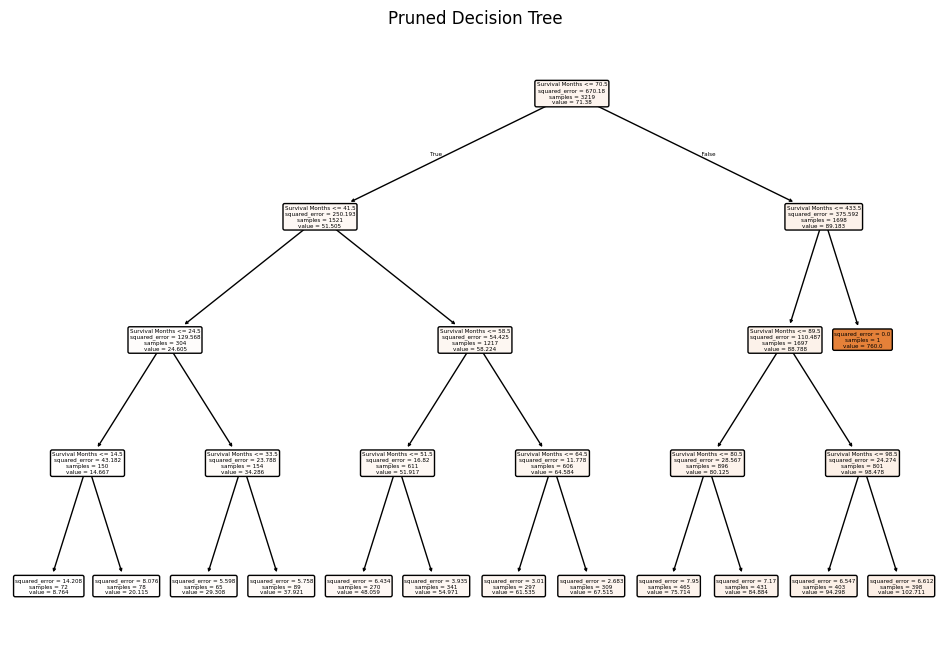

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(pruned_model, feature_names=all_features, filled=True, rounded=True)
plt.title("Pruned Decision Tree")
plt.show()


In [ ]:
# Patient B002565 details
new_patient = pd.DataFrame({
    'Age': [56],
    'Sex': ['Female'],
    'Race': ['White'],
    'Tumour Size': [41],
    'Adopted Status': ['Not Adopted'],
    'Grade':[2],
    'Regional Node Positive': [1],
    'Regional Node Examined': [5],
    'Marital Status': ['Single'],
    'T Stage': ['T3'],
    'N Stage': ['N3'],
    'Estrogen Status': ['Positive'],
    'Progesterone Status': ['Positive']
})


In [ ]:
# Encode categorical variables
new_patient_encoded = pd.get_dummies(new_patient).reindex(columns=X_all.columns, fill_value=0)

In [ ]:
# Predict survival months for patient B002565
predicted_months = pruned_model.predict(new_patient_encoded)
print(f"Predicted Survival Months for Patient B002565: {predicted_months[0]:.2f}")


Predicted Survival Months for Patient B002565: 8.76
